# 用 CatBoost 预测星系 SFR

这份 notebook 复现 arXiv:2608.05531 的机器学习部分：用 REGALADE 的光度、红移和恒星质量，预测 GSWLC-2 给出的 $\log\mathrm{SFR}$。

流程只有一条主线：

$$
\text{读入训练表}
\rightarrow
\text{作者清洗}
\rightarrow
\text{构造 7 个特征}
\rightarrow
\text{2/3--1/3 切分}
\rightarrow
\text{10-fold OOF}
\rightarrow
\text{blind test}
\rightarrow
\text{预测缺失 SFR 的星系}.
$$

这里从作者已经整理好的 Zenodo CSV 开始，不重新执行原始 REGALADE/GSWLC-2 下载和 TOPCAT 交叉匹配。

## 2. 输入特征

作者代码送入 CatBoost 的顺序为

$$
\mathbf{x}
=
(g-r,\ r-z,\ z_{\rm band}-W1,\ W1-W2,\ z_{\rm cos},\ g,\ \log M_\ast).
$$

颜色由星等差得到：

$$
g-r=m_g-m_r,\quad
r-z=m_r-m_z,\quad
z-W1=m_z-m_{W1},\quad
W1-W2=m_{W1}-m_{W2}.
$$

| 特征 | 主要信息 |
|---|---|
| $g-r,\ r-z$ | 光学 SED 形状；受年轻恒星、年龄、金属丰度和尘埃共同影响 |
| $z-W1$ | 光学到 WISE 中红外的跨度，与恒星质量光度比相关 |
| $W1-W2$ | WISE 中红外颜色，可响应暖尘埃或 AGN |
| $z_{\rm cos}$ | 距离和观测波段映射，也可能携带样本选择信息 |
| $g$ | 视亮度 |
| $\log M_\ast$ | 星系尺度和 star-forming main sequence 的强先验 |

$z_{\rm band}$ 表示 z 波段；$z_{\rm cos}$ 表示红移。两者在代码中分别对应 <code>zmag</code> 和 <code>redshift</code>。

## 3. 模型、切分和评价量

CatBoost 使用 1200 棵深度为 10 的树，学习率为 0.05，目标函数为 RMSE，随机种子为 42。它按顺序叠加许多决策树，第 $t$ 轮可概念性地写成

$$
\widehat S^{(t)}(\mathbf{x})
=
\widehat S^{(t-1)}(\mathbf{x})
+\alpha f_t(\mathbf{x}).
$$

$f_t$ 是第 $t$ 棵树学到的误差修正，$\alpha=0.05$ 是学习率。模型最终输出全部树修正量之和。

| 参数 | 在这份复现中的含义 |
|---|---|
| <code>iterations=1200</code> | 训练 1200 棵依次修正误差的树 |
| <code>depth=10</code> | 每棵树最多 10 层，控制单棵树能表达多复杂的特征组合 |
| <code>learning_rate=0.05</code> | 每轮只接受 5% 的新修正，使学习更平缓 |
| <code>loss_function=RMSE</code> | 用预测与参考 $\log\mathrm{SFR}$ 的平方误差指导训练 |
| <code>random_seed=42</code> | 固定随机过程，使重复运行得到相同结果 |
| <code>verbose=False</code> | 只控制日志显示，不改变模型 |
| <code>allow_writing_files=False</code> | 不生成 CatBoost 临时目录，不改变模型 |

作者先把清洗后的样本随机分成

$$
223{,}376\ \text{个 train-validation 行}
\quad+\quad
111{,}688\ \text{个 blind 行}.
$$

10-fold cross-validation 只在 train-validation 中进行。每一行的 OOF 预测来自没有用该行训练的 fold model。这里按行切分，同一 ObjID 仍可能跨 fold。

残差定义为

$$
\Delta S=S_{\rm pred}-S_{\rm ref}.
$$

评价量为

$$
\mathrm{RMSE}
=
\sqrt{\frac{1}{m}\sum_j(\Delta S_j)^2},
\qquad
\mathrm{bias}=\overline{\Delta S},
$$

$$
\sigma
=
\sqrt{\frac{1}{m}\sum_j
(\Delta S_j-\overline{\Delta S})^2},
\qquad
\eta
=
\frac{N(|\Delta S|>3\sigma)}{m}.
$$

代码内部把 $\eta$ 存成 fraction，显示时乘 100%。论文 Table 1 的目标值为：

| 样本 | RMSE | $\sigma$ | bias | $\eta$ |
|---|---:|---:|---:|---:|
| OOF | 0.306 | 0.306 | −0.0001 | 2.290% |
| blind | 0.306 | 0.306 | −0.0015 | 2.302% |

In [3]:
# 1. 环境和路径
from pathlib import Path
import json
import os
import sys
import time

HERE = Path.cwd().resolve()
if HERE.name != "arxiv_2608_05531":
    raise RuntimeError("请从 scripts/experiments/arxiv_2608_05531 启动 notebook")

if Path(sys.prefix).resolve() != (HERE / ".venv").resolve():
    raise RuntimeError("当前 kernel 不是这个小目录的 .venv")

REPO = HERE.parents[2]
DATA_DIR = (
    REPO
    / "external_data/literature_sources/arxiv_2608_05531/zenodo_20695048"
)
RESULT_DIR = REPO / "data_save/reproductions/arxiv_2608_05531/ml/author_baseline"
FIGURE_DIR = REPO / "outputs/reproductions/arxiv_2608_05531/ml/author_baseline"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["MPLCONFIGDIR"] = str(FIGURE_DIR / ".matplotlib")

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split

plt.style.use(HERE / "styles/apj.mplstyle")

print("Python  :", sys.version.split()[0])
print("pandas  :", pd.__version__)
print("CatBoost:", catboost.__version__)

Python  : 3.13.7
pandas  : 3.0.5
CatBoost: 1.2.10


In [2]:
# 2. 固定的文件、特征和模型参数
#
# 监督学习的基本记号：X 是交给模型的输入，y 是希望模型学会预测的答案。
# 本 notebook 的 X 是 7 个星系特征，y 是 GSWLC-2 给出的 logSFR。
TRAIN_FILE = DATA_DIR / "Model_training.csv"
TARGET_FILE = DATA_DIR / "Tobe_predicted.csv"
KNOWN_FILE = DATA_DIR / "regalade_knownSFR.csv"
PUBLISHED_FILE = DATA_DIR / "Allgalaxy_final_version.csv"

# 特征顺序必须固定，因为 NumPy 数组本身不保存列名。
FEATURES = [
    "g-r",
    "r-z",
    "z-W1",
    "W1-W2",
    "redshift",
    "gmag",
    "logM",
]
TARGET = "logSFR"  # 预测目标 y，单位为 dex
SEED = 42  # 固定随机切分和模型随机过程，保证重复运行得到同一结果

# CatBoost 是梯度提升树：后一棵树继续修正前面所有树留下的误差。
# 这些数值来自作者发布的代码，是本次复现需要保持不变的模型设定。
MODEL_PARAMETERS = {
    "iterations": 1200,       # 依次训练 1200 棵树，也就是 1200 次误差修正
    "depth": 10,              # 每棵树最多 10 层；越深越能表达复杂的特征组合
    "learning_rate": 0.05,    # 每棵树只加入 5% 的修正，避免单步改得过猛
    "loss_function": "RMSE",  # 训练时最小化 logSFR 的均方根误差
    "random_seed": SEED,      # 固定 CatBoost 内部的随机过程
    "verbose": False,         # 不逐轮打印 1200 行训练日志
    "allow_writing_files": False,  # 不生成额外的 catboost_info 临时目录
}

# 同时固定 NumPy 随机数；它不改变物理量，只保证计算可复现。
np.random.seed(SEED)

In [3]:
# 3. 读入作者整理好的训练表
training_raw = pd.read_csv(
    TRAIN_FILE,
    dtype={"ObjID": "string"},
)

print("原始行数:", f"{len(training_raw):,}")
display(training_raw.head())

原始行数: 335,264


,name,ra_1,dec_1,dL/Mpc,redshift,gmag,rmag,imag,zmag,W1mag,W2mag,logM,ObjID,ra_2,dec_2,logSFR,Separation
0,WISEA J000000.16-001108.,0.000678,-0.185734,943.663452,0.195292,18.45907,17.76127,17.49363,17.23962,17.08096,17.09530,10.853800,1.23765719090521728E18,0.000686,-0.185726,1.039,0.040729
1,WISEA J000000.74-091320.,0.003000,-9.222250,622.607666,0.133762,17.68532,16.97518,16.86335,16.42787,16.55680,16.93343,10.868290,1.23765294852564582E18,0.003088,-9.222298,0.796,0.357273
2,WISEA J000001.03+003229.,0.004296,0.541327,433.582397,0.095523,18.26209,17.84292,17.57575,17.46463,17.68214,18.17101,9.948013,1.23766327792776013E18,0.004314,0.541300,0.382,0.116818
3,Z 456-13,0.008951,15.881594,85.861092,0.020097,15.43113,14.84447,NaN,14.40498,14.66064,15.16602,10.189400,1.23765649672431206E18,0.008759,15.881756,-0.239,0.884366
4,WISEA J000002.58+150228.,0.010650,15.041130,695.736572,0.148134,18.37000,17.61189,NaN,17.01452,17.04978,17.36345,10.719385,1.2376564956505705E18,0.010741,15.041193,0.790,0.389271


## 4. 作者的清洗规则

作者把所有数值列中的精确 $0.0$ 改成 NaN，再把 $\pm\infty$ 改成 NaN，最后只删除缺失 <code>logSFR</code> 的行。

训练表中有 200 行满足

$$
\log_{10}\!\left[
\frac{\mathrm{SFR}}{M_\odot\,\mathrm{yr}^{-1}}
\right]=0.
$$

这些行会被作者规则删除。这个数值在物理上对应
$\mathrm{SFR}=1\,M_\odot\,\mathrm{yr}^{-1}$，因此该清洗假设值得在后续敏感性实验中单独检查。这里先保持作者基线。

In [4]:
# 4. 复现作者的数值清洗
training = training_raw.copy()
numeric_columns = training.select_dtypes(include="number").columns

zero_counts = (training[numeric_columns] == 0.0).sum()
training[numeric_columns] = training[numeric_columns].replace(0.0, np.nan)
training = training.replace([np.inf, -np.inf], np.nan)
training = training.dropna(subset=[TARGET]).copy()

print("logSFR=0 的行数:", int(zero_counts[TARGET]))
print("清洗后行数     :", f"{len(training):,}")

display(zero_counts[zero_counts > 0].rename("zero_count").to_frame())

logSFR=0 的行数: 200
清洗后行数     : 335,064


,zero_count
logSFR,200
Separation,62


In [5]:
# 5. 构造颜色和红移特征
#
# 星等差就是颜色。颜色描述 SED 在两个波段之间的相对形状，
# 比单个波段的绝对亮度更直接地反映恒星族、尘埃和 AGN 信息。
def add_features(table, redshift_column):
    # copy() 避免在原始表上原地增加列，便于区分原始量和派生特征。
    table = table.copy()
    table["g-r"] = table["gmag"] - table["rmag"]
    table["r-z"] = table["rmag"] - table["zmag"]
    table["z-W1"] = table["zmag"] - table["W1mag"]
    table["W1-W2"] = table["W1mag"] - table["W2mag"]
    # 训练表的红移列叫 redshift，待预测表中叫 z；统一成模型使用的列名。
    table["redshift"] = table[redshift_column]
    return table


training = add_features(training, redshift_column="redshift")
display(training[FEATURES + [TARGET]].head())

,g-r,r-z,z-W1,W1-W2,redshift,gmag,logM,logSFR
0,0.69780,0.52165,0.15866,-0.01434,0.195292,18.45907,10.853800,1.039
1,0.71014,0.54731,-0.12893,-0.37663,0.133762,17.68532,10.868290,0.796
2,0.41917,0.37829,-0.21751,-0.48887,0.095523,18.26209,9.948013,0.382
3,0.58666,0.43949,-0.25566,-0.50538,0.020097,15.43113,10.189400,-0.239
4,0.75811,0.59737,-0.03526,-0.31367,0.148134,18.37000,10.719385,0.790


In [6]:
# 6. 按作者方式切分 train-validation 和 blind
#
# 先留出 1/3 的 blind 数据。它在 final_model.fit() 之前不会交给模型，
# 因而可以检查模型对未参与训练的数据行是否仍然有效。
train_val, blind = train_test_split(
    training,
    test_size=1 / 3,      # 1/3 留作 blind，2/3 留作训练和交叉验证
    random_state=SEED,   # 固定哪些行进入哪一侧
    shuffle=True,        # 切分前随机打乱数据行
)

# X 是模型输入矩阵：每一行是一条星系记录，每一列是一个特征。
# y 是监督标签向量：同一行对应的 GSWLC-2 reference logSFR。
X_train_val = train_val[FEATURES].to_numpy()
y_train_val = train_val[TARGET].to_numpy()
X_blind = blind[FEATURES].to_numpy()
y_blind = blind[TARGET].to_numpy()

# CatBoost 可以原生处理 X 中的 NaN，所以这里记录数量但不做均值填补。
print("train-validation:", f"{len(train_val):,}")
print("blind           :", f"{len(blind):,}")
print("带缺失特征的 train-validation 行:", np.isnan(X_train_val).any(axis=1).sum())
print("带缺失特征的 blind 行          :", np.isnan(X_blind).any(axis=1).sum())

train-validation: 223,376
blind           : 111,688
带缺失特征的 train-validation 行: 216
带缺失特征的 blind 行          : 128


### 行级 blind 的解释边界

作者采用随机“行切分”，没有按 ObjID 分组。同一个 ObjID 可能在交叉匹配表中出现多次，并分别进入 train 和 blind。

下一格只量化这个现象，不改变作者基线。它决定了 blind 指标应解释为 **row-held-out validation**，而不是独立星系级验证。

In [7]:
# 7. 简单检查 ObjID 是否跨越 train/blind
train_objids = set(train_val["ObjID"].dropna())
blind_objid_in_train = blind["ObjID"].isin(train_objids)

overlap_summary = pd.Series(
    {
        "train 与 blind 重叠的唯一 ObjID": len(
            train_objids.intersection(set(blind["ObjID"].dropna()))
        ),
        "ObjID 已在训练侧出现的 blind 行": int(blind_objid_in_train.sum()),
        "blind 行占比": float(blind_objid_in_train.mean()),
    }
)
display(overlap_summary.to_frame("value"))

,value
train 与 blind 重叠的唯一 ObjID,41960.000000
ObjID 已在训练侧出现的 blind 行,52384.000000
blind 行占比,0.469021


## 5. CatBoost 和 10-fold OOF

在机器学习中，<code>fit(X, y)</code> 表示让模型从已知输入和答案中学习映射；<code>predict(X)</code> 表示把学到的映射应用到输入，只输出预测而不再学习。

10-fold 把 train-validation 平均分成 10 份。每一轮用其中 9 份 <code>fit</code>，对剩下 1 份 <code>predict</code>：

$$
\underbrace{9\ \text{folds}}_{\text{fit}}
\longrightarrow
\text{model}
\longrightarrow
\underbrace{1\ \text{fold}}_{\text{predict}}.
$$

每个 fold 都新建一个 CatBoost 模型，防止上一轮已经看过的验证信息带入下一轮。验证折的预测写回 <code>oof_prediction</code> 的原行位置。十轮结束后，每一行恰好被预测一次，这组结果称为 out-of-fold（OOF）预测。

最终用于 blind 和外部目录预测的模型会重新初始化，并只在完整 train-validation 上训练一次。

In [8]:
# 8. 两个小工具：新建模型、计算指标
def new_model():
    # 每次调用都返回一棵尚未训练的新模型。交叉验证的不同 fold 不能共用已训练模型。
    return CatBoostRegressor(**MODEL_PARAMETERS)


def evaluate(reference, prediction):
    # residual > 0 表示高估 SFR，residual < 0 表示低估；单位都是 dex。
    residual = prediction - reference
    sigma = np.std(residual)  # 去除平均偏移后，残差分布的宽度

    return {
        "r2": r2_score(reference, prediction),  # 模型解释了多少标签方差，越接近 1 越好
        "rmse": np.sqrt(mean_squared_error(reference, prediction)),  # 大误差权重更高
        "mae": mean_absolute_error(reference, prediction),  # 绝对误差的典型尺度
        "bias": np.mean(residual),  # 整体系统性高估或低估
        "sigma": sigma,
        "eta": np.mean(np.abs(residual) > 3 * sigma),  # 3-sigma 离群行占比
        "residual": residual,  # 保留逐行残差，供画图和保存结果使用
    }


def numbers_only(metrics):
    # 表格只展示汇总数字；逐行 residual 数组不塞进单个表格单元。
    return {name: value for name, value in metrics.items() if name != "residual"}

In [9]:
# 9. 10-fold out-of-fold 训练
#
# KFold 只负责产生每一轮的行号：fit_rows 用来学习，validation_rows 用来考试。
folds = KFold(n_splits=10, shuffle=True, random_state=SEED)

# 先为每一行预留一个预测位置。循环结束后，这里不应再有 NaN。
oof_prediction = np.full(len(train_val), np.nan)
# 同时记录每一行由第几个 fold 模型预测，方便以后追踪。
oof_fold = np.zeros(len(train_val), dtype=int)

start = time.perf_counter()

for fold, (fit_rows, validation_rows) in enumerate(
    folds.split(X_train_val),
    start=1,
):
    # 这一轮从全新的模型开始，避免验证折的信息从前一轮泄漏进来。
    model = new_model()

    # fit：用 9/10 数据的 7 个特征学习如何逼近 reference logSFR。
    model.fit(X_train_val[fit_rows], y_train_val[fit_rows])

    # predict：对模型从未用于 fit 的 1/10 数据生成 logSFR 预测。
    oof_prediction[validation_rows] = model.predict(
        X_train_val[validation_rows]
    )
    oof_fold[validation_rows] = fold
    print(f"fold {fold:02d}/10 完成")

oof_runtime = time.perf_counter() - start
print(f"OOF 用时: {oof_runtime:.1f} s")

fold 01/10 完成
fold 02/10 完成
fold 03/10 完成
fold 04/10 完成
fold 05/10 完成
fold 06/10 完成
fold 07/10 完成
fold 08/10 完成
fold 09/10 完成
fold 10/10 完成
OOF 用时: 174.8 s


In [10]:
# 10. OOF 指标
# 每一行都由没有使用该行训练的模型预测，因此这里评价的是 OOF 泛化误差。
oof_metrics = evaluate(y_train_val, oof_prediction)
display(
    pd.Series(numbers_only(oof_metrics), name="10-fold OOF").to_frame()
)

,10-fold OOF
r2,0.762637
rmse,0.306283
mae,0.196837
bias,-0.000083
sigma,0.306283
eta,0.022903


In [11]:
# 11. 训练 final model，并评价 row-held-out blind
#
# OOF 的 10 个模型只用于交叉验证。现在重新创建一个 final model，
# 让它利用全部 train-validation 数据学习，供 blind 和外部目录预测。
start = time.perf_counter()

final_model = new_model()
final_model.fit(X_train_val, y_train_val)  # blind 数据没有进入这一步
blind_prediction = final_model.predict(X_blind)  # 只预测，不更新模型

final_fit_runtime = time.perf_counter() - start
blind_metrics = evaluate(y_blind, blind_prediction)

metric_table = pd.DataFrame(
    {
        "OOF": numbers_only(oof_metrics),
        "blind": numbers_only(blind_metrics),
    }
).T

print(f"final model 用时: {final_fit_runtime:.1f} s")
display(metric_table)

# 把本次计算值和论文 Table 1 并排查看，判断复现是否一致。
paper_table = pd.DataFrame(
    {
        "OOF": {"rmse": 0.306, "sigma": 0.306, "bias": -0.0001, "eta": 0.02290},
        "blind": {"rmse": 0.306, "sigma": 0.306, "bias": -0.0015, "eta": 0.02302},
    }
).T
display(paper_table.rename_axis("论文 Table 1"))

final model 用时: 18.3 s


,r2,rmse,mae,bias,sigma,eta
OOF,0.762637,0.306283,0.196837,-0.000083,0.306283,0.022903
blind,0.759595,0.306300,0.196062,-0.001531,0.306296,0.023019


,rmse,sigma,bias,eta
论文 Table 1,,,,
OOF,0.306,0.306,-0.0001,0.02290
blind,0.306,0.306,-0.0015,0.02302


## 6. 复现 Fig. 2

左列比较预测与 GSWLC-2 reference logSFR：

- 红虚线：1:1；
- 粉色区域：$\pm3\sigma$；
- 颜色：每个 hexbin 的对象数。

右列给出残差 $\Delta S$ 的概率密度：

- 红虚线：平均残差 $\mu$；
- 橙色点线：$\mu\pm3\sigma$。

上排是 OOF，下排是 row-held-out blind。

Matplotlib is building the font cache; this may take a moment.
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman


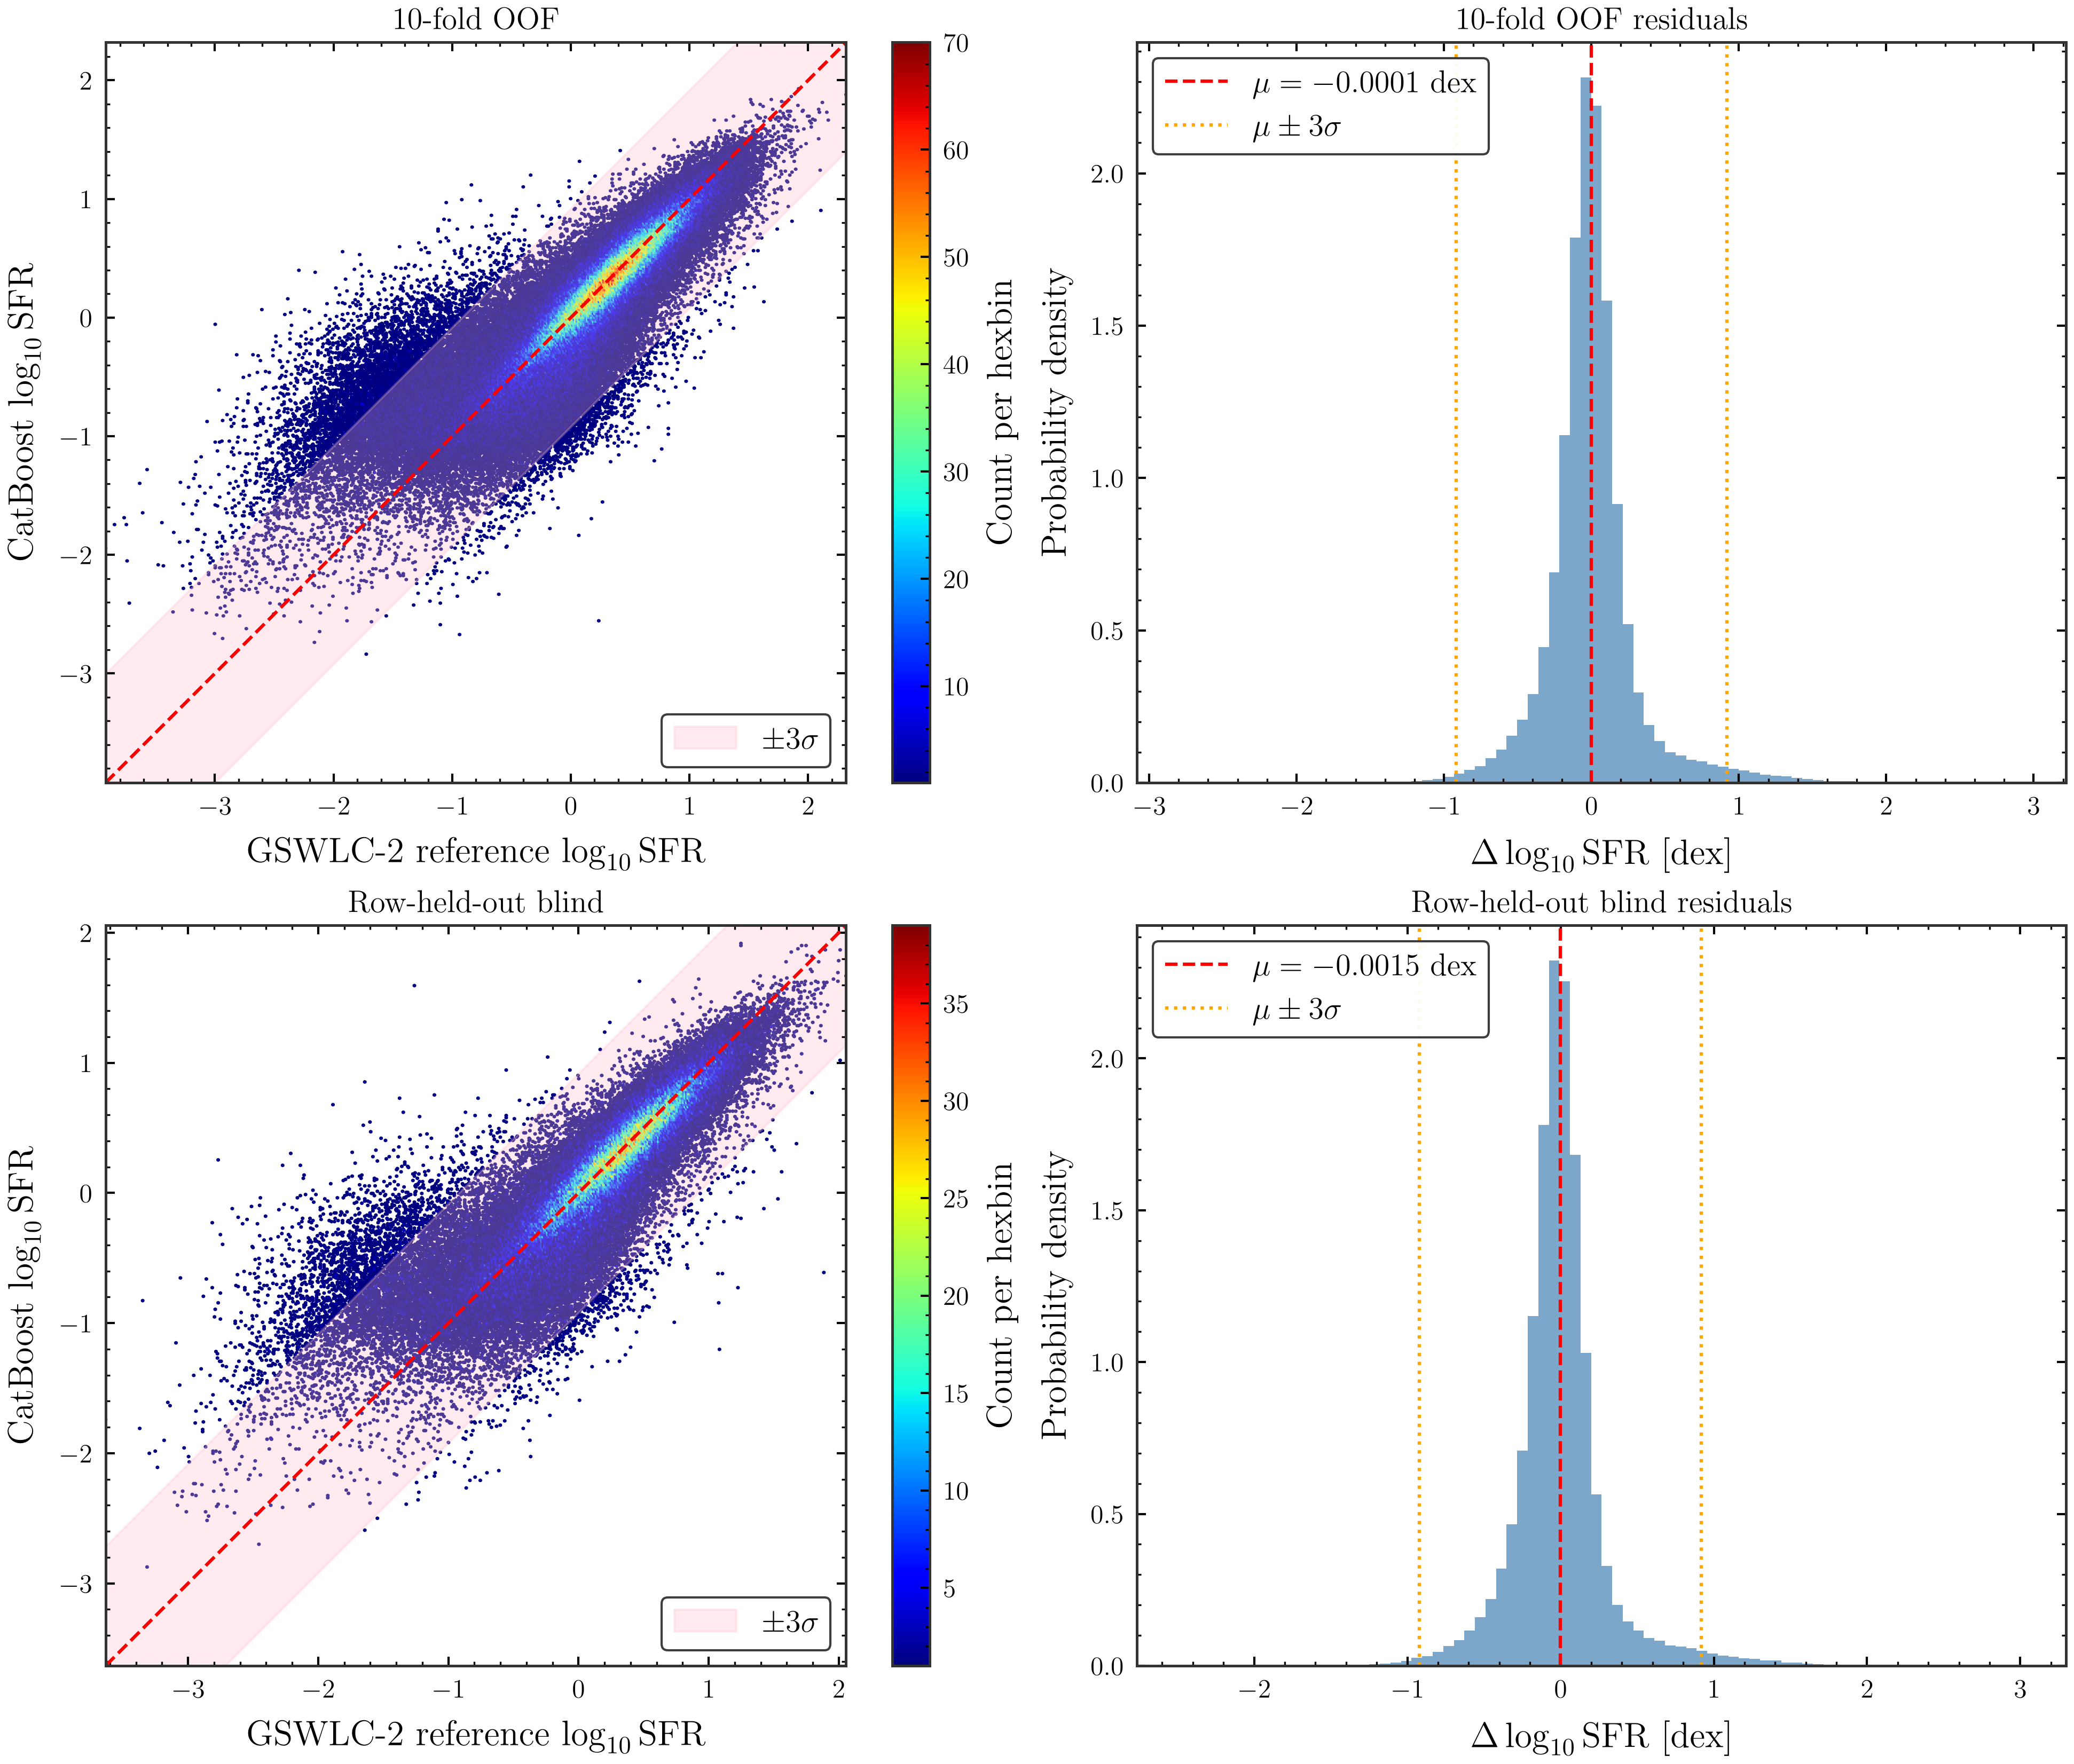

In [12]:
# 12. 画出 OOF 和 blind 的预测、残差
samples = [
    ("10-fold OOF", y_train_val, oof_prediction, oof_metrics),
    ("Row-held-out blind", y_blind, blind_prediction, blind_metrics),
]

with plt.rc_context(fname=HERE / "styles/apj.mplstyle"):
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13.5, 11),
        constrained_layout=True,
    )

    for row, (label, reference, prediction, metrics) in enumerate(samples):
        sigma = metrics["sigma"]
        residual = metrics["residual"]

        # Predicted versus reference
        ax = axes[row, 0]
        limits = [
            min(reference.min(), prediction.min()),
            max(reference.max(), prediction.max()),
        ]
        density = ax.hexbin(
            reference,
            prediction,
            gridsize=500,
            mincnt=1,
            cmap="jet",
            rasterized=True,
        )
        fig.colorbar(density, ax=ax, label="Count per hexbin")

        line = np.linspace(*limits, 300)
        ax.fill_between(
            line,
            line - 3 * sigma,
            line + 3 * sigma,
            color="pink",
            alpha=0.3,
            label=r"$\pm3\sigma$",
        )
        ax.plot(limits, limits, "r--")
        ax.set(xlim=limits, ylim=limits, title=label)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel(r"GSWLC-2 reference $\log_{10}\mathrm{SFR}$")
        ax.set_ylabel(r"CatBoost $\log_{10}\mathrm{SFR}$")
        ax.legend(loc="lower right")

        # Residual distribution
        ax = axes[row, 1]
        mu = residual.mean()
        ax.hist(residual, bins=80, density=True, color="steelblue", alpha=0.7)
        ax.axvline(mu, color="red", linestyle="--", label=rf"$\mu={mu:.4f}$ dex")
        ax.axvline(
            mu - 3 * sigma,
            color="orange",
            linestyle=":",
            label=r"$\mu\pm3\sigma$",
        )
        ax.axvline(mu + 3 * sigma, color="orange", linestyle=":")
        ax.set(
            title=f"{label} residuals",
            xlabel=r"$\Delta\log_{10}\mathrm{SFR}$ [dex]",
            ylabel="Probability density",
        )
        ax.legend(loc="upper left")

    figure_pdf = FIGURE_DIR / "fig2_catboost_reproduction.pdf"
    figure_png = FIGURE_DIR / "fig2_catboost_reproduction.png"
    fig.savefig(figure_pdf, dpi=500)
    fig.savefig(figure_png, dpi=500)
    plt.show()
    plt.close(fig)

## 7. 预测 325,807 个缺失 SFR 的星系

作者对 <code>Tobe_predicted.csv</code> 只构造颜色和 redshift，然后使用 final model 预测。

CatBoost 可以原生处理特征 NaN。下面同时给出两个直观的 domain-shift 指标：

1. 至少缺一个特征的目标行数；
2. 至少一个特征超出 train-validation min–max 的目标行数。

这些统计只描述外推风险，不删除对象，也不修改预测。

In [13]:
# 13. 外部目录预测和简单的 domain-shift 统计
#
# 这些星系没有 reference logSFR，因此不能再次 fit 或直接计算预测误差。
# 我们只按训练时完全相同的规则构造 7 个输入特征，再调用 final model。
target_galaxies = pd.read_csv(TARGET_FILE)
target_galaxies = add_features(target_galaxies, redshift_column="z")

X_target = target_galaxies[FEATURES].to_numpy()
target_prediction = final_model.predict(X_target)  # 每个输出都是一个预测 logSFR

# 机器学习在训练范围附近通常更可靠。下面只标记简单的外推风险：
# 某个目标特征是否落在 train-validation 的逐列最小值和最大值之外。
train_min = train_val[FEATURES].min()
train_max = train_val[FEATURES].max()
outside = (
    target_galaxies[FEATURES].lt(train_min)
    | target_galaxies[FEATURES].gt(train_max)
)

print("目标星系数                 :", f"{len(target_galaxies):,}")
print("至少缺一个特征的行         :", target_galaxies[FEATURES].isna().any(axis=1).sum())
print("至少一个特征超出训练范围的行:", outside.any(axis=1).sum())

domain_summary = pd.DataFrame(
    {
        "train median": train_val[FEATURES].median(),
        "target median": target_galaxies[FEATURES].median(),
        "target missing fraction": target_galaxies[FEATURES].isna().mean(),
        "target outside fraction": outside.mean(),
    }
)
display(domain_summary)

目标星系数                 : 325,807
至少缺一个特征的行         : 6090
至少一个特征超出训练范围的行: 15558


,train median,target median,target missing fraction,target outside fraction
g-r,0.781595,0.490486,0.009948,0.000789
r-z,0.589390,0.306102,0.002904,0.000694
z-W1,-0.172820,-0.634274,0.004012,0.000107
W1-W2,-0.439620,-0.576000,0.009325,0.000018
redshift,0.094476,0.035284,0.000000,0.014518
gmag,17.725965,17.767653,0.009260,0.003656
logM,10.689077,9.141468,0.000000,0.035742


In [14]:
# 14. 与作者发布的最终预测逐行比较，并重建最终目录
#
# 这一步是复现校验：如果数据处理、特征顺序和模型参数都一致，
# 我们的 target_prediction 应逐行等于作者发布的 predicted 部分。
known_sfr = pd.read_csv(KNOWN_FILE)
published = pd.read_csv(PUBLISHED_FILE, float_precision="round_trip")
published_prediction = published.loc[
    published["origin"] == "predicted",
    "final_logSFR",
].to_numpy()

product_difference = target_prediction - published_prediction
print("发布预测对照:")
print("  max |difference|:", np.abs(product_difference).max(), "dex")
print("  RMSE difference :", np.sqrt(np.mean(product_difference**2)), "dex")

# 最终目录由两类对象拼接：已有 GSWLC-2 SFR 的对象，以及 ML 预测对象。
known_output = known_sfr[
    ["name", "ra_1", "dec_1", "dL/Mpc", "logM", "logSFR"]
].rename(
    columns={
        "ra_1": "ra",
        "dec_1": "dec",
        "logSFR": "final_logSFR",
    }
)
known_output["origin"] = "GSWLC-2"

predicted_output = target_galaxies[
    ["name", "ra", "dec", "dL/Mpc", "logM"]
].copy()
predicted_output["final_logSFR"] = target_prediction
predicted_output["origin"] = "predicted"

reproduced_catalog = pd.concat(
    [known_output, predicted_output],
    ignore_index=True,
)
print("重建最终目录行数:", f"{len(reproduced_catalog):,}")

发布预测对照:
  max |difference|: 4.440892098500626e-16 dex
  RMSE difference : 4.8769360070261807e-17 dex
重建最终目录行数: 364,148


In [ ]:
# 15. 保存最常用的结果
#
# OOF 表保存交叉验证预测；blind 表保存留出集预测；target 表保存正式目录预测。
# source_row 保留原 CSV 行号，使任何异常预测都能追溯到输入记录。
oof_output = pd.DataFrame(
    {
        "source_row": train_val.index,
        "fold": oof_fold,
        "reference_logSFR": y_train_val,
        "predicted_logSFR": oof_prediction,
        "residual": oof_metrics["residual"],
    }
)
blind_output = pd.DataFrame(
    {
        "source_row": blind.index,
        "reference_logSFR": y_blind,
        "predicted_logSFR": blind_prediction,
        "residual": blind_metrics["residual"],
    }
)
target_output = target_galaxies.copy()
target_output["Predicted_logSFR"] = target_prediction

oof_output.to_csv(RESULT_DIR / "oof_predictions.csv", index=False)
blind_output.to_csv(RESULT_DIR / "blind_test_predictions.csv", index=False)
target_output.to_csv(RESULT_DIR / "Predicted_logSFR.csv", index=False)
reproduced_catalog.to_csv(
    RESULT_DIR / "Allgalaxy_final_version_reproduced.csv",
    index=False,
)
# 保存已经 fit 的 final model，以后可以直接加载并预测相同的 7 个特征。
final_model.save_model(RESULT_DIR / "catboost_final.cbm")

metrics_output = {
    "oof": numbers_only(oof_metrics),
    "blind": numbers_only(blind_metrics),
    "oof_runtime_seconds": oof_runtime,
    "final_fit_runtime_seconds": final_fit_runtime,
    "published_prediction_max_difference_dex": float(
        np.abs(product_difference).max()
    ),
}
(RESULT_DIR / "metrics.json").write_text(
    json.dumps(metrics_output, indent=2) + "\n",
    encoding="utf-8",
)

print("结果目录:", RESULT_DIR)
print("图目录  :", FIGURE_DIR)

## 8. 结果应如何解释

这条基线复现回答的是：

> 给定作者整理的 REGALADE–GSWLC-2 匹配样本，这 7 个特征能多好地预测 GSWLC-2 reference logSFR？

约 0.306 dex 的残差宽度对应预测/参考比值约 $\times2$ 的乘性尺度。约 2.3% 的 $3\sigma$ 离群率高于单一 Gaussian 的 0.27%，说明残差尾部较重。

三个主要边界：

1. row-held-out blind 中存在重复 ObjID 跨 split；
2. 待预测目录比训练样本更低红移、低质量，并含更多缺失特征；
3. 模型没有提供逐星系预测不确定度。

这些问题适合放进后续独立的 sensitivity notebook；本 notebook 保持作者 baseline 简洁可读。